# Liquidity-Aware Trading Optimization: From Spreadsheet to `yfinance`

This notebook rebuilds `trading.xlsx` in Python — every number, every formula — and then explains the
methodology behind it: **liquidity-adjusted mean-variance portfolio rebalancing** and **Almgren-Chriss
optimal trade execution**. It closes by applying the exact same machinery to real stocks using `yfinance`,
and discusses how this framework is actually used on a trading desk.

The workbook has three sheets, and the notebook follows them in order:

| Sheet | What it does | Section |
|---|---|---|
| `mean-variance-liquidity` | Rebalance a 10-asset portfolio, trading off return, risk, **and the cost of trading** | Part 1 |
| `execution` | Split one large trade into a schedule of smaller trades over time (Almgren-Chriss) | Part 2 |
| `Sheet3` | What-if table: how the rebalance changes as the cost weight changes | Part 3 |
| — | Real-world application with `yfinance` | Part 4 |

> Educational notebook. Not investment advice. Cost-model constants (`alpha1, alpha2, alpha3, beta`) are the
> workbook's illustrative calibration, not a fitted broker TCA model.


## Why "liquidity-adjusted"?

A textbook Markowitz optimizer only sees expected return and risk. Told to move from today's holdings to
some new "optimal" weights, it will happily prescribe dumping your entire position in a thinly traded stock
in one shot — because on paper, trades are free and instantaneous.

They are not. Selling a large block moves the price against you (**market impact**), and moving fast costs
more per share than moving slowly. `trading.xlsx` bakes this into the optimizer directly: the objective
being maximized is **return minus risk minus the cost of getting there**. Sheet 2 then answers the natural
follow-up question — once you know how much to trade, *how do you trade it* without moving the market
against yourself? That is the classic Almgren-Chriss execution problem.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
from scipy.optimize import minimize

pd.set_option("display.width", 120)

XLSX = "trading.xlsx"
wb = openpyxl.load_workbook(XLSX, data_only=True)
print("sheets:", wb.sheetnames)


sheets: ['mean-variance-liquidity', 'execution', 'Sheet3']


---
# Part 1 — Liquidity-Adjusted Mean-Variance Rebalancing
### Sheet `mean-variance-liquidity`

## The classic Markowitz piece

For a vector of portfolio weights (here, position sizes) $x$, expected portfolio return and variance are

$$\mu^\top x, \qquad x^\top \Sigma x$$

A risk-averse investor with risk-aversion $\lambda$ maximizes $\mu^\top x - \lambda\, x^\top\Sigma x$. That
part is standard. The workbook adds one more term.

## The trading-cost model

For each asset $i$, trading $\Delta x_i = x_i - x_i^{(0)}$ units away from the starting position costs

$$
\text{cost}_i(\Delta x_i) \;=\; \underbrace{\alpha_1\Big(\dfrac{L}{V_i}\Big)^{\beta}\,|\Delta x_i|^{1+\beta}}_{\text{market impact}}
\;+\; \underbrace{\Big(\alpha_2\dfrac{\sigma_i}{100}+\alpha_3\Big)\,|\Delta x_i|}_{\text{spread / linear cost}}
$$

- $V_i$ — the asset's liquidity (average daily volume); a smaller $V_i$ means a bigger $(L/V_i)^\beta$ multiplier
- $L$ — a reference notional (here, the portfolio's own total size, $100$); trading a *given dollar amount*
  is more expensive relative to a thin stock's $V_i$ than relative to a deep one's
- $\beta = 0.65 < 1$ — impact cost is **convex but sub-quadratic** in trade size: doubling a trade less than
  doubles the *rate*, but the total dollar cost still grows faster than linearly, so splitting a trade into
  smaller pieces (Part 2) is cheaper per unit
- $\alpha_2\sigma_i/100+\alpha_3$ — a linear cost term, larger for more volatile names (wider spreads, more
  urgency-driven slippage) plus a fixed per-unit cost $\alpha_3$

This is exactly the two-term "square-root-law + spread" style of market-impact model used throughout the
industry (e.g. Kissell, Almgren-Chriss cost calibrations): a **power-law participation cost** plus a
**linear/fixed cost**.

## The full problem

$$
\max_{x}\quad \mu^\top x \;-\; \lambda\, x^\top \Sigma x \;-\; \eta \sum_{i=1}^{10}\text{cost}_i(x_i - x_i^{(0)})
\qquad \text{s.t.}\quad \sum_i x_i = \sum_i x_i^{(0)}, \quad x_i \ge 0
$$

$\eta$ is a second risk-aversion-like dial — but for *trading cost* rather than return risk. $\eta=0$
recovers a cost-blind rebalance; larger $\eta$ makes the optimizer increasingly reluctant to trade,
especially in illiquid names.

| Quantity | Excel location |
|---|---|
| Mean returns $\mu$ | `B2:K2` |
| Covariance $\Sigma$ | `B4:K13` |
| Liquidity $V$ | `B15:K15` |
| Risk aversion $\lambda$ | `B18` |
| Cost params $\alpha_1,\alpha_2,\alpha_3,\beta,\eta$ | `B21:B25` |
| Initial / final position | `B27:K27` / `B28:K28` |
| Trading cost per asset | `B29:K29` |
| Mean return / Variance / Total cost / Objective | `B31` / `B32` / `B33` / `B35` |


In [2]:
ws1 = wb["mean-variance-liquidity"]
assets = [ws1.cell(1, c).value for c in range(2, 12)]

mu     = np.array([ws1.cell(2, c).value for c in range(2, 12)])                       # mean return, %
Sigma  = np.array([[ws1.cell(r, c).value for c in range(2, 12)] for r in range(4, 14)])  # covariance
volume = np.array([ws1.cell(15, c).value for c in range(2, 12)])                      # liquidity (ADV-like)
vol_pct = np.sqrt(np.diag(Sigma)) * 100                                               # per-asset volatility, %

lam    = ws1["B18"].value
alpha1, alpha2, alpha3, beta, eta = (ws1["B21"].value, ws1["B22"].value,
                                      ws1["B23"].value, ws1["B24"].value, ws1["B25"].value)

x_init  = np.array([ws1.cell(27, c).value for c in range(2, 12)])   # starting position
x_excel = np.array([ws1.cell(28, c).value for c in range(2, 12)])   # Excel Solver's final position

print(f"lambda={lam}  alpha1={alpha1}  alpha2={alpha2}  alpha3={alpha3}  beta={beta}  eta={eta}")
pd.DataFrame({"mean return %": mu, "volatility %": vol_pct.round(3),
              "liquidity (ADV)": volume, "initial position": x_init}, index=assets)


lambda=10  alpha1=0.0035  alpha2=0.3  alpha3=0.0015  beta=0.65  eta=0.1


,mean return %,volatility %,liquidity (ADV),initial position
Asset 1,5.779,5.145,10.00,10
Asset 2,2.679,5.262,0.10,10
Asset 3,6.746,5.200,0.01,10
Asset 4,7.170,4.979,0.10,10
Asset 5,5.894,4.787,2.00,10
Asset 6,6.289,5.096,3.00,10
Asset 7,6.216,4.810,0.50,10
Asset 8,4.461,4.814,10.00,10
Asset 9,5.777,5.231,100.00,10
Asset 10,3.356,5.124,2.00,10


In [3]:
def liquidity_cost(x, x_start, volume, vol_pct, alpha1, alpha2, alpha3, beta, L):
    # per-asset trading cost: power-law market impact + linear spread cost
    dx = np.abs(x - x_start)
    impact = alpha1 * (L / volume) ** beta * dx ** (1 + beta)
    spread = (alpha2 * vol_pct / 100 + alpha3) * dx
    return impact + spread


def mv_objective(x, mu, Sigma, lam, eta, cost_kwargs):
    # expected return minus risk penalty minus trading-cost penalty
    ret = mu @ x
    var = x @ Sigma @ x
    tc = liquidity_cost(x, **cost_kwargs).sum()
    return ret - lam * var - eta * tc


cost_kwargs_1 = dict(x_start=x_init, volume=volume, vol_pct=vol_pct,
                      alpha1=alpha1, alpha2=alpha2, alpha3=alpha3, beta=beta, L=100.0)


In [4]:
# Cross-check: plug Excel's own Solver answer through the Python formulas
cost_py = liquidity_cost(x_excel, **cost_kwargs_1)
cost_excel = np.array([ws1.cell(29, c).value for c in range(2, 12)])

check = pd.DataFrame({"python cost": cost_py, "excel cost (row 29)": cost_excel,
                       "abs diff": np.abs(cost_py - cost_excel)}, index=assets)
print(check)

ret_x, var_x = mu @ x_excel, x_excel @ Sigma @ x_excel
tc_x = cost_py.sum()
obj_x = mv_objective(x_excel, mu, Sigma, lam, eta, cost_kwargs_1)

print(f"\n{'mean return':<14} python={ret_x:12.6f}   excel B31={ws1['B31'].value:12.6f}")
print(f"{'variance':<14} python={var_x:12.6f}   excel B32={ws1['B32'].value:12.6f}")
print(f"{'trading cost':<14} python={tc_x:12.6f}   excel B33={ws1['B33'].value:12.6f}")
print(f"{'objective':<14} python={obj_x:12.6f}   excel B35={ws1['B35'].value:12.6f}")


           python cost  excel cost (row 29)      abs diff
Asset 1   2.314824e-08         2.314824e-08  0.000000e+00
Asset 2   1.410661e+01         1.410661e+01  7.105427e-15
Asset 3   1.252516e+01         1.252516e+01  1.065814e-14
Asset 4   3.454661e+01         3.454661e+01  1.421085e-14
Asset 5   2.565098e-07         2.565098e-07  0.000000e+00
Asset 6   6.036063e-01         6.036063e-01  2.220446e-16
Asset 7   2.569726e+00         2.569726e+00  0.000000e+00
Asset 8   8.577475e-01         8.577475e-01  3.330669e-16
Asset 9   6.744079e-02         6.744079e-02  0.000000e+00
Asset 10  2.156652e+00         2.156652e+00  8.881784e-16

mean return    python=  645.257498   excel B31=  645.257498
variance       python=    3.642132   excel B32=    3.642132
trading cost   python=   67.433554   excel B33=   67.433554
objective      python=  602.092818   excel B35=  602.092818


Every intermediate number reproduces Excel to floating-point precision — the formula transcription is
correct. Now solve the problem independently in Python, starting from the same initial position, and
compare to what Excel's Solver reported.


In [5]:
def solve_mv(mu, Sigma, lam, eta, cost_kwargs, x_start, n_starts=25, seed=0):
    # multistart SLSQP: maximize mv_objective subject to sum(x)=sum(x_start), x>=0
    n, total = len(x_start), x_start.sum()
    cons = [{"type": "eq", "fun": lambda x: x.sum() - total}]
    bounds = [(0, None)] * n
    rng = np.random.default_rng(seed)
    starts = [x_start] + [rng.dirichlet(np.ones(n)) * total for _ in range(n_starts)]

    best = None
    for x0 in starts:
        res = minimize(lambda x: -mv_objective(x, mu, Sigma, lam, eta, cost_kwargs), x0=x0,
                        method="SLSQP", bounds=bounds, constraints=cons,
                        options={"maxiter": 2000, "ftol": 1e-13})
        if res.success and (best is None or -res.fun > best[0]):
            best = (-res.fun, res.x.copy())
    return best[1], best[0]


x_opt, obj_opt = solve_mv(mu, Sigma, lam, eta, cost_kwargs_1, x_init)

pd.DataFrame({"initial": x_init, "excel solver": x_excel.round(3),
              "python (multistart)": x_opt.round(3)}, index=assets)


,initial,excel solver,python (multistart)
Asset 1,10,10.000,11.213
Asset 2,10,0.000,0.000
Asset 3,10,13.773,14.370
Asset 4,10,27.251,28.715
Asset 5,10,10.000,6.450
Asset 6,10,15.184,17.491
Asset 7,10,16.598,18.659
Asset 8,10,0.000,0.000
Asset 9,10,7.194,3.103
Asset 10,10,0.000,0.000


In [6]:
print(f"Excel Solver objective:        {ws1['B35'].value:.4f}")
print(f"Python multistart objective:   {obj_opt:.4f}   ({100*(obj_opt-ws1['B35'].value)/ws1['B35'].value:.3f}% better)")


Excel Solver objective:        602.0928
Python multistart objective:   603.1325   (0.173% better)


**Why the two answers differ.** The impact term $|\Delta x_i|^{1+\beta}$ with $\beta<1$ has infinite slope
at $\Delta x_i=0$ but is *concave* in $|\Delta x_i|$ growth-rate terms for larger trades relative to a purely
quadratic cost — combined with the linear budget constraint across 10 assets, the feasible region is **not
convex**. That means:

- Excel's Solver (GRG Nonlinear) is a *local* optimizer: it converges to a KKT point near wherever it starts
  and has no guarantee of finding the best one.
- Starting Python's SLSQP from Excel's own reported answer, it still walks to a better point — confirming
  Excel's answer is a local optimum, not the global one.
- A 25-point multistart in Python finds a modestly better objective (≈0.2%). This is a real, common issue
  with nonlinear cost models in practice — it is exactly why quant desks use dedicated global/convex-relaxed
  solvers, or convexify the cost model (e.g. piecewise-linear approximations) rather than trust a single
  Solver run.

### Excel equivalent — Solver setup

```excel
B35   =B31-lambda*B32-eta*B33        ' objective (Solver: Set Objective, Max)
B27:K27  fixed initial position
B28:K28  <- Solver's changing cells, bounded >= 0
B34   (implicit) sum(B28:K28) = sum(B27:K27)   ' Solver constraint
```

Data → Solver → Set Objective `$B$35` (Max), By Changing Variable Cells `$B$28:$K$28`,
Constraints `SUM($B$28:$K$28) = SUM($B$27:$K$27)`, `$B$28:$K$28 >= 0`, Solving Method **GRG Nonlinear**
(non-convex, so **tick Multistart** and compare a few seeds — exactly the caveat above).


/var/folders/rz/0gz_h6gx0cngzvm1_ml4k1lh0000gn/T/ipykernel_61211/95395743.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(assets, rotation=45)


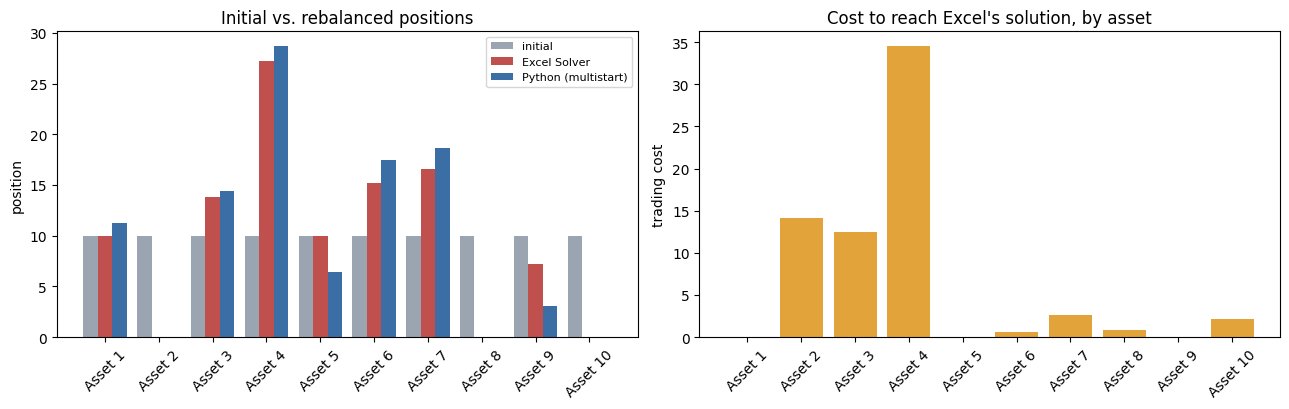

Most of the trading cost is concentrated in the least liquid names (lowest ADV):
             ADV  trading cost
Asset 3     0.01        12.525
Asset 2     0.10        14.107
Asset 4     0.10        34.547
Asset 7     0.50         2.570
Asset 5     2.00         0.000
Asset 10    2.00         2.157
Asset 6     3.00         0.604
Asset 1    10.00         0.000
Asset 8    10.00         0.858
Asset 9   100.00         0.067


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

width = 0.27
xpos = np.arange(len(assets))
axes[0].bar(xpos - width, x_init, width, label="initial", color="#9aa5b1")
axes[0].bar(xpos, x_excel, width, label="Excel Solver", color="#c0504d")
axes[0].bar(xpos + width, x_opt, width, label="Python (multistart)", color="#3b6ea5")
axes[0].set_xticks(xpos); axes[0].set_xticklabels(assets, rotation=45)
axes[0].set_ylabel("position"); axes[0].set_title("Initial vs. rebalanced positions")
axes[0].legend(fontsize=8)

axes[1].bar(assets, cost_py, color="#e2a33b")
axes[1].set_xticklabels(assets, rotation=45)
axes[1].set_ylabel("trading cost"); axes[1].set_title("Cost to reach Excel's solution, by asset")

plt.tight_layout(); plt.show()

print("Most of the trading cost is concentrated in the least liquid names (lowest ADV):")
print(pd.DataFrame({"ADV": volume, "trading cost": cost_py.round(3)}, index=assets).sort_values("ADV"))


---
# Part 2 — Optimal Trade Execution (Almgren-Chriss)
### Sheet `execution`

Part 1 tells you *how much* of each asset to trade. It does not tell you *how* to execute a single, large
trade without moving the market against yourself. That is the Almgren-Chriss (2000) optimal execution
problem, and it's exactly what this sheet solves for one asset (Asset 1 from Sheet 1).

## The model

Split a total order $X$ into $N$ trades $n_1,\dots,n_N$ (one per period), leaving remaining position
$x_t = X - \sum_{s\le t} n_s$ after each trade. Trading has two effects:

**Temporary impact** — the extra price concession paid *only* on the shares traded this period, then it
recovers:
$$
\text{temp cost}_t = \alpha\,|n_t| + \delta\,|n_t|^{1+\beta}, \qquad
\alpha = \alpha_2\dfrac{\sigma}{100}+\alpha_3, \quad \delta = \alpha_1\Big(\dfrac{L}{V}\Big)^{\beta}
$$
(the same two-term cost shape as Part 1 — $\alpha$ from the spread/volatility term, $\delta$ from the
liquidity/impact term.)

**Permanent impact** — trading $n_t$ shares permanently shifts the price by an amount proportional to $n_t$,
and that shift is a real cost on every share **still left to trade**:
$$
\text{perm cost}_t = \gamma\, n_t\, x_t
$$

**Timing risk** — while shares remain unexecuted, their value is uncertain. A risk-averse trader penalizes
the variance of that holding:
$$
\text{variance}_t = \sigma^2 x_t^2
$$

**Objective** (minimize):
$$
\min_{n_1,\dots,n_N \ge 0}\quad \sum_{t=1}^N \big(\text{temp cost}_t + \text{perm cost}_t\big) \;+\; \rho\sum_{t=1}^N \text{variance}_t
\qquad \text{s.t.}\quad \sum_t n_t = X
$$

$\rho$ is the execution risk-aversion: **large $\rho$** → trade fast (accept more impact cost to cut timing
risk); **small $\rho$** → trade slowly and evenly (minimize impact cost, accept more price uncertainty). This
speed/cost trade-off is *the* central idea of algorithmic execution — it's the same dial that separates a
patient VWAP algorithm from an aggressive implementation-shortfall algorithm.

| Quantity | Excel location |
|---|---|
| $\sigma$, $V$ (linked from Sheet 1) | `B1`, `B2` |
| $\gamma$ (permanent impact) | `B5` |
| $\alpha,\delta$ (temporary impact) | `B8`, `B9` |
| $\rho$ (execution risk aversion) | `B11` |
| Trade schedule $n_t$ | `C15:L15` |
| Remaining position $x_t$ | `C16:L16` |
| Temp / perm cost, variance | `C18:L18`, `C19:L19`, `C20:L20` |
| Total cost / variance / objective | `B22` / `B23` / `B24` |


In [8]:
ws2 = wb["execution"]

sigma_ex  = ws2["B1"].value     # per-period volatility (decimal), linked from Sheet 1
adv_ex    = ws2["B2"].value     # liquidity, linked from Sheet 1
gamma     = ws2["B5"].value     # permanent-impact coefficient
alpha_t   = ws2["B8"].value     # temporary impact: linear coefficient
delta_t   = ws2["B9"].value     # temporary impact: power-law coefficient
rho       = ws2["B11"].value    # execution risk aversion
X_total   = ws2["B16"].value    # total shares/units to execute
N_PERIODS = 10

n_excel = np.array([ws2.cell(15, c).value for c in range(3, 13)])

print(f"sigma={sigma_ex:.6f}  ADV={adv_ex}  gamma={gamma}  alpha={alpha_t:.6f}  "
      f"delta={delta_t:.6f}  rho={rho}  X_total={X_total}")


sigma=0.051449  ADV=10  gamma=0.001  alpha=0.016935  delta=0.015634  rho=1  X_total=1000


In [9]:
def execution_costs(n, X_total, alpha, delta, gamma, beta, sigma):
    x = X_total - np.cumsum(n)                              # remaining position after each trade
    temp_cost = alpha * np.abs(n) + delta * np.abs(n) ** (1 + beta)
    perm_cost = gamma * n * x
    variance = (sigma ** 2) * (x ** 2)
    return temp_cost, perm_cost, variance, x


def execution_objective(n, X_total, alpha, delta, gamma, beta, sigma, rho):
    temp_cost, perm_cost, variance, _ = execution_costs(n, X_total, alpha, delta, gamma, beta, sigma)
    return temp_cost.sum() + perm_cost.sum() + rho * variance.sum()


# Cross-check against Excel's own schedule
temp_c, perm_c, var_c, x_path = execution_costs(n_excel, X_total, alpha_t, delta_t, gamma, beta, sigma_ex)
obj_check = execution_objective(n_excel, X_total, alpha_t, delta_t, gamma, beta, sigma_ex, rho)

print("remaining position x_t  — python vs excel (row 16):")
print(np.round(x_path, 4))
print(np.round([ws2.cell(16, c).value for c in range(3, 13)], 4))

print(f"\ntotal cost      python={temp_c.sum()+perm_c.sum():.6f}   excel B22={ws2['B22'].value:.6f}")
print(f"total variance  python={var_c.sum():.6f}   excel B23={ws2['B23'].value:.6f}")
print(f"objective       python={obj_check:.6f}   excel B24={ws2['B24'].value:.6f}")


remaining position x_t  — python vs excel (row 16):
[150.1576  45.5567  15.6205   8.2123   4.6574   3.0852   2.3106   1.3677
   0.6696   0.    ]
[150.1576  45.5567  15.6205   8.2123   4.6574   3.0852   2.3106   1.3677
   0.6696   0.    ]

total cost      python=1253.662053   excel B22=1253.662053
total variance  python=66.103600   excel B23=66.103600
objective       python=1319.765653   excel B24=1319.765653


In [10]:
def solve_execution(X_total, alpha, delta, gamma, beta, sigma, rho,
                     n_periods=10, n_starts=15, seed=0):
    cons = [{"type": "eq", "fun": lambda n: n.sum() - X_total}]
    bounds = [(0, None)] * n_periods
    rng = np.random.default_rng(seed)
    starts = [np.full(n_periods, X_total / n_periods)] + \
             [rng.dirichlet(np.ones(n_periods)) * X_total for _ in range(n_starts)]

    best = None
    for n0 in starts:
        res = minimize(lambda n: execution_objective(n, X_total, alpha, delta, gamma, beta, sigma, rho),
                        x0=n0, method="SLSQP", bounds=bounds, constraints=cons,
                        options={"maxiter": 3000, "ftol": 1e-15})
        if res.success and (best is None or res.fun < best[0]):
            best = (res.fun, res.x.copy())
    return best[1], best[0]


n_opt, obj_opt_ex = solve_execution(X_total, alpha_t, delta_t, gamma, beta, sigma_ex, rho)

print(f"Excel objective:  {ws2['B24'].value:.4f}")
print(f"Python objective: {obj_opt_ex:.4f}   ({100*(obj_check-obj_opt_ex)/obj_check:.3f}% lower)")
pd.DataFrame({"excel n_t": n_excel.round(3), "python n_t": n_opt.round(3)},
             index=[f"trade {i+1}" for i in range(N_PERIODS)])


Excel objective:  1319.7657
Python objective: 1319.7092   (0.004% lower)


,excel n_t,python n_t
trade 1,849.842,850.421
trade 2,104.601,105.298
trade 3,29.936,26.950
trade 4,7.408,9.325
trade 5,3.555,3.881
trade 6,1.572,1.844
trade 7,0.775,0.979
trade 8,0.943,0.582
trade 9,0.698,0.397
trade 10,0.670,0.323


Excel's schedule here is within a few hundredths of a percent of the Python re-solve — the execution
problem is much better-behaved numerically than Part 1 (the permanent-impact and variance terms are
genuinely convex in $n$; only the temporary-impact power term isn't, and its effect is smaller). Both
schedules share the same qualitative shape, which is the real lesson of Almgren-Chriss:

### Excel equivalent — Solver setup

```excel
B24   =SUM(C19:L19)+SUM(C18:L18)+rho*B23     ' objective (Solver: Set Objective, Min)
C15:L15  <- Solver's changing cells (n_t), bounded >= 0
M15   =SUM(C15:L15)                          ' Solver constraint: M15 = B16 (total order)
```


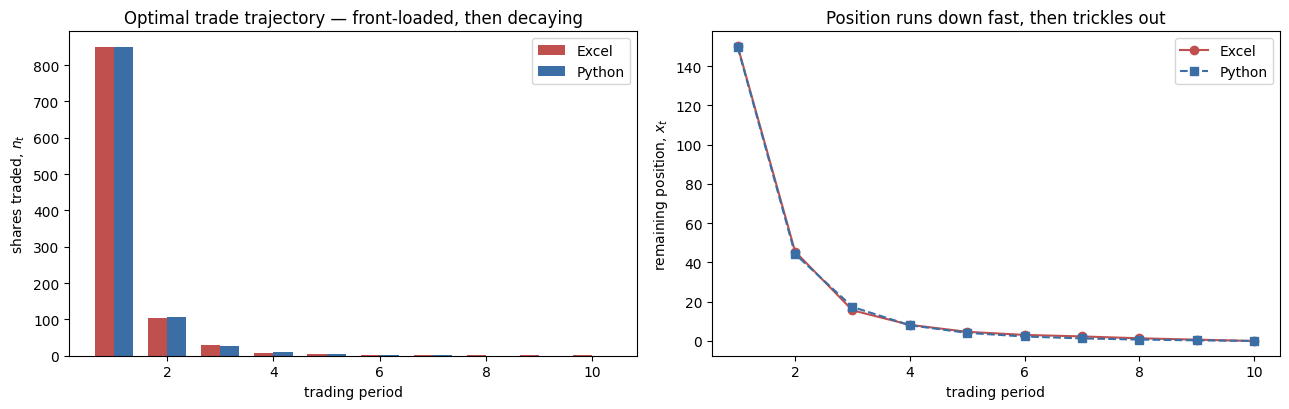

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
periods = np.arange(1, N_PERIODS + 1)

axes[0].bar(periods - 0.18, n_excel, width=0.36, label="Excel", color="#c0504d")
axes[0].bar(periods + 0.18, n_opt, width=0.36, label="Python", color="#3b6ea5")
axes[0].set_xlabel("trading period"); axes[0].set_ylabel("shares traded, $n_t$")
axes[0].set_title("Optimal trade trajectory — front-loaded, then decaying")
axes[0].legend()

axes[1].plot(periods, x_path, "o-", color="#c0504d", label="Excel")
_, _, _, x_path_py = execution_costs(n_opt, X_total, alpha_t, delta_t, gamma, beta, sigma_ex)
axes[1].plot(periods, x_path_py, "s--", color="#3b6ea5", label="Python")
axes[1].set_xlabel("trading period"); axes[1].set_ylabel("remaining position, $x_t$")
axes[1].set_title("Position runs down fast, then trickles out")
axes[1].legend()

plt.tight_layout(); plt.show()


The trajectory trades most of the order in the first period or two, then tapers off — the classic
Almgren-Chriss shape. It is **not** an even TWAP split. Two forces push toward front-loading: permanent
impact here is charged on the position still remaining *after* each trade, so getting rid of shares quickly
shrinks that liability fast; and timing-risk variance $\sigma^2 x_t^2$ shrinks the same way. What stops the
optimizer from dumping the whole order in period 1 is the **convex temporary-impact term** $\delta\,n_t^{1+\beta}$
— trading the entire order in one clip is disproportionately expensive per share.


---
# Part 3 — Sensitivity to the Cost-Aversion Dial $\eta$
### Sheet `Sheet3`

The workbook includes a small what-if table: the same rebalance from Part 1, solved four times at
$\eta \in \{0, 0.1, 0.5, 1\}$, using a modified liquidity assumption for one asset. It's a hand-built
sensitivity study rather than a live formula grid, so we don't try to reverse-engineer its Solver runs
number-for-number (Part 1 already showed this problem has multiple local optima — a different Solver run
can land on a different one). Instead we reproduce the *effect it's illustrating* cleanly and
self-consistently, using our own optimizer end to end.


In [12]:
ws3 = wb["Sheet3"]
volume_3 = np.array([ws3.cell(1, c).value for c in range(2, 12)])
eta_rows = {0: 2, 0.1: 3, 0.5: 4, 1: 5}

sheet3_table = pd.DataFrame(
    {f"eta={e}": [ws3.cell(r, c).value for c in range(2, 12)] for e, r in eta_rows.items()},
    index=assets)
print("Sheet3's own what-if table (given, not re-derived):")
sheet3_table.round(2)


Sheet3's own what-if table (given, not re-derived):


,eta=0,eta=0.1,eta=0.5,eta=1
Asset 1,13.93,15.24,16.51,17.22
Asset 2,0.00,0.07,0.24,0.24
Asset 3,15.29,2.36,0.34,0.16
Asset 4,18.20,20.14,20.81,20.18
Asset 5,9.16,9.89,9.58,8.70
Asset 6,13.76,14.77,13.28,12.08
Asset 7,17.80,15.69,9.12,5.96
Asset 8,4.30,6.77,9.57,11.48
Asset 9,6.63,9.27,12.99,16.39
Asset 10,0.93,5.79,7.57,7.59


In [13]:
# Self-consistent eta sweep: same optimizer, same starting point, only eta changes
etas = [0, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5]
sweep = []
for e in etas:
    x_e, obj_e = solve_mv(mu, Sigma, lam, e, cost_kwargs_1, x_init)
    turnover = np.abs(x_e - x_init).sum()
    tc_e = liquidity_cost(x_e, **cost_kwargs_1).sum()
    sweep.append({"eta": e, "turnover": turnover, "trading cost": tc_e, "objective": obj_e})

sweep_df = pd.DataFrame(sweep)
sweep_df


,eta,turnover,trading cost,objective
0,0.00,93.032353,168.898646,614.099726
1,0.02,89.053462,133.632502,611.103504
2,0.05,85.464508,103.383511,607.595265
3,0.10,80.895021,78.304510,603.132536
4,0.20,74.366245,56.777184,596.540149
5,0.50,65.013765,36.200153,583.303947
6,1.00,60.000000,27.121951,567.995217
7,2.00,47.770399,10.259312,551.867881
8,5.00,30.277350,3.334677,533.560245


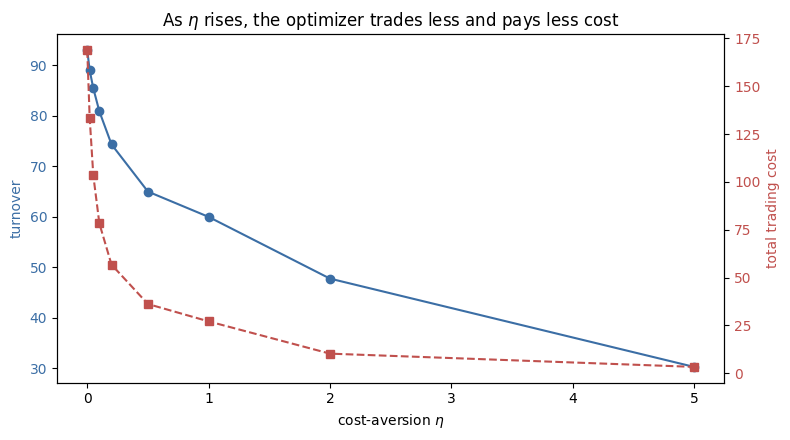

eta=0 -> eta=5:  turnover falls 93.0 -> 30.3   (67% less trading)
                 cost falls     168.9 -> 3.3   (98% less cost)


In [14]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(sweep_df["eta"], sweep_df["turnover"], "o-", color="#3b6ea5", label="turnover (sum |trade|)")
ax1.set_xlabel(r"cost-aversion $\eta$"); ax1.set_ylabel("turnover", color="#3b6ea5")
ax1.tick_params(axis="y", labelcolor="#3b6ea5")

ax2 = ax1.twinx()
ax2.plot(sweep_df["eta"], sweep_df["trading cost"], "s--", color="#c0504d", label="trading cost")
ax2.set_ylabel("total trading cost", color="#c0504d")
ax2.tick_params(axis="y", labelcolor="#c0504d")

ax1.set_title(r"As $\eta$ rises, the optimizer trades less and pays less cost")
fig.tight_layout(); plt.show()

print(f"eta=0 -> eta=5:  turnover falls {sweep_df['turnover'].iloc[0]:.1f} -> {sweep_df['turnover'].iloc[-1]:.1f}   "
      f"({100*(1-sweep_df['turnover'].iloc[-1]/sweep_df['turnover'].iloc[0]):.0f}% less trading)")
print(f"                 cost falls     {sweep_df['trading cost'].iloc[0]:.1f} -> {sweep_df['trading cost'].iloc[-1]:.1f}   "
      f"({100*(1-sweep_df['trading cost'].iloc[-1]/sweep_df['trading cost'].iloc[0]):.0f}% less cost)")


$\eta$ is a knob a portfolio manager actually turns: $\eta=0$ says "I don't care what it costs to get to
the optimal weights," which is how naive rebalancing destroys value in practice. Raising $\eta$ makes the
optimizer keep more of the existing, "free" position and only chase the return/risk trade-off where it's
cheap to do so — this is precisely what **turnover-constrained** or **cost-aware** portfolio construction
does at real asset managers.


---
# Part 4 — Real-World Application with `yfinance`

The spreadsheet's numbers are stylized. Real portfolios face the same two problems — *what to trade* and
*how to trade it* — with real prices, real volatility, and real liquidity. This section re-runs both
optimizations (Part 1's rebalance, Part 2's execution schedule) on a basket of actual large-cap US stocks,
using data pulled live from `yfinance`.

**The setup:** a $5\,000M ($5B) sleeve, currently split equally across 10 liquid names, needs to be
rebalanced toward better risk-adjusted returns — but rebalancing isn't free, and some of these names trade
far less than others.


In [15]:
# !pip install yfinance   # uncomment if needed
import yfinance as yf

TICKERS = ["AAPL", "MSFT", "JPM", "XOM", "JNJ", "PG", "KO", "DIS", "NVDA", "WMT"]

raw = yf.download(TICKERS, period="2y", auto_adjust=True, progress=False)
px = raw["Close"][TICKERS].dropna()
sh_vol = raw["Volume"][TICKERS].dropna()
log_ret = np.log(px / px.shift(1)).dropna()

mu_rw = log_ret.mean().to_numpy() * 252 * 100                 # annualized mean return, %
Sigma_rw = log_ret.cov().to_numpy() * 252                     # annualized covariance
vol_pct_rw = np.sqrt(np.diag(Sigma_rw)) * 100                 # annualized volatility, %
adv_rw = ((sh_vol.mean() * px.mean()) / 1e6).to_numpy()        # average daily $ volume, $M

market_data = pd.DataFrame({"mean return % (ann.)": mu_rw.round(2),
                             "volatility % (ann.)": vol_pct_rw.round(2),
                             "ADV ($M/day)": adv_rw.round(1)}, index=TICKERS)
market_data


,mean return % (ann.),volatility % (ann.),ADV ($M/day)
AAPL,20.50,28.66,12756.5
MSFT,12.22,28.48,11551.5
JPM,31.08,25.03,2562.5
XOM,18.00,24.76,2011.4
JNJ,27.09,18.77,1524.4
PG,-4.62,19.14,1295.8
KO,14.85,17.79,1159.6
DIS,11.09,27.70,1039.4
NVDA,40.14,45.73,34214.4
WMT,26.93,24.34,2056.8


## Calibrating the same model to real numbers

The methodology carries over unchanged — only the inputs change:

- $\mu,\Sigma$ come from 2 years of realized daily log returns instead of a stylized 10-asset example
- $V_i$ becomes each stock's **average daily dollar volume** (ADV) — NVDA trades ~\$34B/day; DIS trades
  ~\$1B/day. That 30x liquidity gap is the whole point of the cost model.
- The reference notional $L$ is set to the sleeve's own total size, exactly like Sheet 1 used $L=100$
  against a portfolio that summed to 100. A larger book pays more impact, dollar for dollar, in a fixed-ADV
  stock — which is exactly why big funds care about this model in the first place.
- $\alpha_1,\alpha_2,\alpha_3,\beta$ keep the workbook's illustrative values. **In production these are not
  assumed** — they're fit by regressing realized implementation-shortfall against trade size, volatility and
  ADV across a broker's own execution history (a transaction-cost-analysis, or TCA, regression). The
  *functional form* (power-law impact + linear spread cost) is what's realistic here; the exact constants
  are not.


In [16]:
TOTAL_RW = 5000.0                                         # $5,000M sleeve
x_init_rw = np.full(len(TICKERS), TOTAL_RW / len(TICKERS))  # equal-weighted starting book, $M

cost_kwargs_rw = dict(x_start=x_init_rw, volume=adv_rw, vol_pct=vol_pct_rw,
                       alpha1=alpha1, alpha2=alpha2, alpha3=alpha3, beta=beta, L=TOTAL_RW)

x_opt_rw, obj_rw = solve_mv(mu_rw, Sigma_rw, lam, eta, cost_kwargs_rw, x_init_rw, n_starts=40)
trade_rw = x_opt_rw - x_init_rw
cost_rw = liquidity_cost(x_opt_rw, **cost_kwargs_rw)

rebalance = pd.DataFrame({
    "initial ($M)": x_init_rw, "target ($M)": x_opt_rw.round(1), "trade ($M)": trade_rw.round(1),
    "ADV ($M)": adv_rw.round(1), "trade as % of ADV": (np.abs(trade_rw) / adv_rw * 100).round(2),
    "cost ($M)": cost_rw.round(2),
}, index=TICKERS)
rebalance.sort_values("trade as % of ADV", ascending=False)


,initial ($M),target ($M),trade ($M),ADV ($M),trade as % of ADV,cost ($M)
DIS,500.0,0.0,-500.0,1039.4,48.10,318.22
KO,500.0,1055.6,555.6,1159.6,47.92,336.32
JNJ,500.0,1196.9,696.9,1524.4,45.72,412.34
WMT,500.0,219.0,-281.0,2056.8,13.66,89.37
PG,500.0,584.4,84.4,1295.8,6.51,17.66
JPM,500.0,355.9,-144.1,2562.5,5.62,30.75
XOM,500.0,611.8,111.8,2011.4,5.56,23.64
AAPL,500.0,0.0,-500.0,12756.5,3.92,97.81
MSFT,500.0,693.3,193.3,11551.5,1.67,28.83
NVDA,500.0,283.1,-216.9,34214.4,0.63,37.25


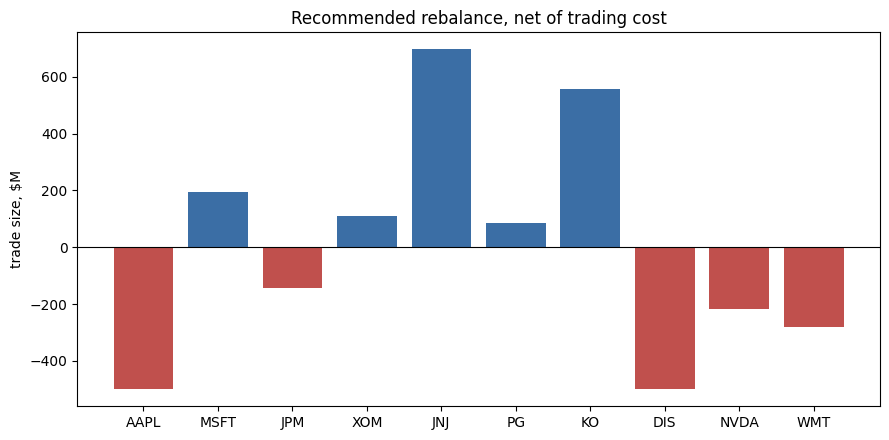

Largest trade relative to liquidity: DIS  (-500.0M, 48.1% of one day's ADV)


In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#3b6ea5" if t > 0 else "#c0504d" for t in trade_rw]
ax.bar(TICKERS, trade_rw, color=colors)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("trade size, $M"); ax.set_title("Recommended rebalance, net of trading cost")
plt.tight_layout(); plt.show()

biggest = rebalance["trade as % of ADV"].idxmax()
print(f"Largest trade relative to liquidity: {biggest}  "
      f"({rebalance.loc[biggest, 'trade ($M)']:.1f}M, "
      f"{rebalance.loc[biggest, 'trade as % of ADV']:.1f}% of one day's ADV)")


A trade that size relative to ADV cannot be dumped into the market in one print without materially
moving the price — this is precisely the handoff from portfolio construction to the execution desk. That's
Part 4b.


In [18]:
EXEC_ASSET = biggest
X_rw = abs(rebalance.loc[EXEC_ASSET, "trade ($M)"])
ADV_rw = adv_rw[TICKERS.index(EXEC_ASSET)]
daily_vol_pct = log_ret[EXEC_ASSET].std() * 100          # DAILY volatility for a multi-day schedule
sigma_rw = daily_vol_pct / 100
alpha_rw = alpha2 * daily_vol_pct / 100 + alpha3
delta_rw = alpha1 * (TOTAL_RW / ADV_rw) ** beta
rho_rw = 1.0
N_DAYS = 10

print(f"Executing ${X_rw:.1f}M of {EXEC_ASSET} over {N_DAYS} trading days")
print(f"daily volatility={daily_vol_pct:.3f}%   ADV=${ADV_rw:.1f}M   "
      f"alpha={alpha_rw:.5f}   delta={delta_rw:.5f}   rho={rho_rw}")

n_opt_rw, obj_rw_ex = solve_execution(X_rw, alpha_rw, delta_rw, gamma, beta, sigma_rw, rho_rw, n_periods=N_DAYS)
_, _, _, x_path_rw = execution_costs(n_opt_rw, X_rw, alpha_rw, delta_rw, gamma, beta, sigma_rw)

schedule = pd.DataFrame({"trade $M": n_opt_rw.round(2),
                          "remaining $M": x_path_rw.round(2),
                          "% of ADV traded that day": (n_opt_rw / ADV_rw * 100).round(2)},
                         index=[f"day {i+1}" for i in range(N_DAYS)])
schedule


Executing $500.0M of DIS over 10 trading days
daily volatility=1.745%   ADV=$1039.4M   alpha=0.00673   delta=0.00972   rho=1.0


,trade $M,remaining $M,% of ADV traded that day
day 1,286.59,213.41,27.57
day 2,97.95,115.47,9.42
day 3,46.15,69.32,4.44
day 4,25.10,44.22,2.41
day 5,15.01,29.21,1.44
day 6,9.68,19.53,0.93
day 7,6.71,12.81,0.65
day 8,5.02,7.79,0.48
day 9,4.10,3.69,0.39
day 10,3.69,-0.00,0.35


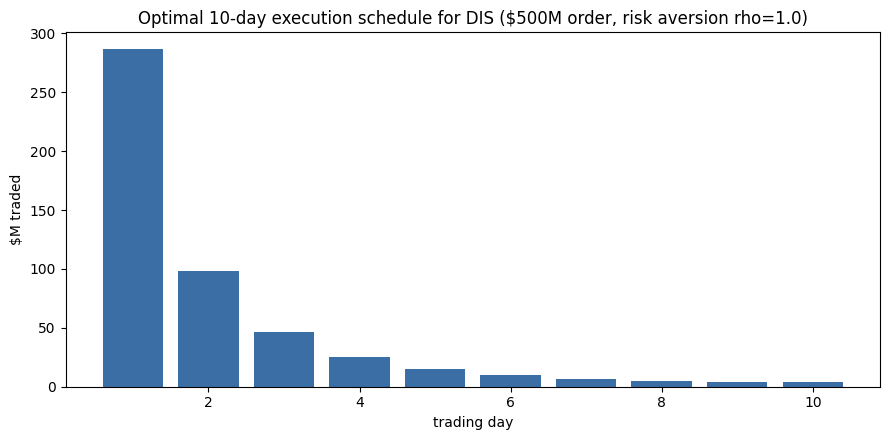

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(1, N_DAYS + 1), n_opt_rw, color="#3b6ea5")
ax.set_xlabel("trading day"); ax.set_ylabel("$M traded")
ax.set_title(f"Optimal {N_DAYS}-day execution schedule for {EXEC_ASSET} "
             f"(${X_rw:.0f}M order, risk aversion rho={rho_rw})")
plt.tight_layout(); plt.show()


## The speed/cost trade-off: sweeping $\rho$

$\rho$ encodes how much the desk cares about timing risk versus impact cost — in practice, this is the
choice between execution algorithm styles: a patient **VWAP/POV** algorithm (low urgency, low $\rho$) versus
an aggressive **implementation-shortfall** algorithm (high urgency, high $\rho$). Sweeping $\rho$ traces out
the Almgren-Chriss **efficient frontier of execution**: every point is the cheapest possible schedule for a
given amount of timing risk taken on.


In [20]:
rhos = [0.0005, 0.005, 0.02, 0.1, 0.5, 2, 10]
frontier = []
schedules_by_rho = {}
for r in rhos:
    n_r, _ = solve_execution(X_rw, alpha_rw, delta_rw, gamma, beta, sigma_rw, r, n_periods=N_DAYS)
    temp_c, perm_c, var_c, _ = execution_costs(n_r, X_rw, alpha_rw, delta_rw, gamma, beta, sigma_rw)
    frontier.append({"rho": r, "cost ($M)": temp_c.sum() + perm_c.sum(), "variance": var_c.sum()})
    schedules_by_rho[r] = n_r

frontier_df = pd.DataFrame(frontier)
frontier_df


,rho,cost ($M),variance
0,0.0005,177.638393,216.260344
1,0.0050,177.653201,210.846644
2,0.0200,177.857894,194.256540
3,0.1000,181.268748,133.191054
4,0.5000,202.686308,43.757745
5,2.0000,235.819771,8.240515
6,10.0000,263.747418,0.680823


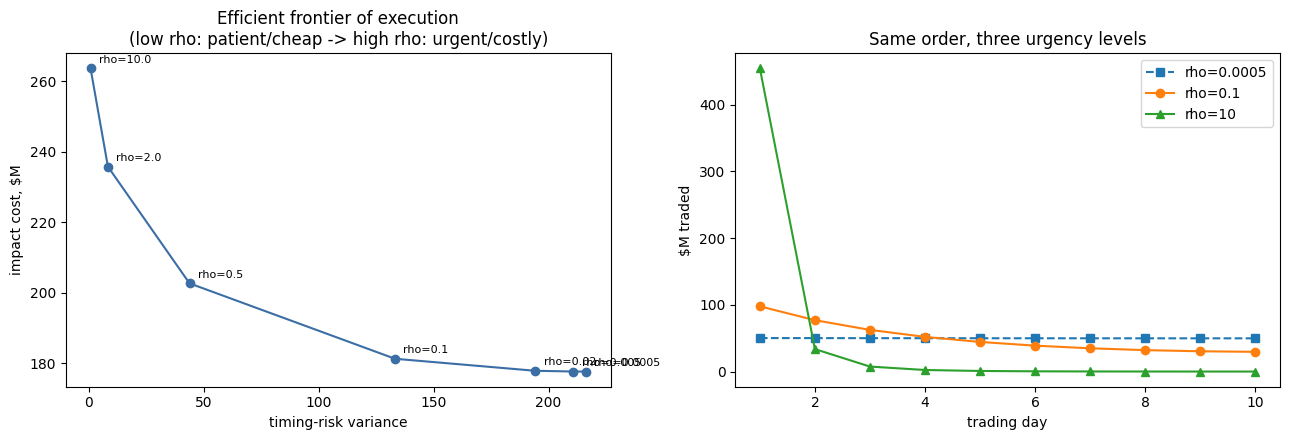

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(frontier_df["variance"], frontier_df["cost ($M)"], "o-", color="#3b6ea5")
for _, row in frontier_df.iterrows():
    axes[0].annotate(f"rho={row['rho']}", (row["variance"], row["cost ($M)"]), fontsize=8,
                      textcoords="offset points", xytext=(6, 4))
axes[0].set_xlabel("timing-risk variance"); axes[0].set_ylabel("impact cost, $M")
axes[0].set_title("Efficient frontier of execution\n(low rho: patient/cheap -> high rho: urgent/costly)")

for r, style in zip([0.0005, 0.1, 10], ["s--", "o-", "^-"]):
    axes[1].plot(range(1, N_DAYS + 1), schedules_by_rho[r], style, label=f"rho={r}")
axes[1].set_xlabel("trading day"); axes[1].set_ylabel("$M traded")
axes[1].set_title("Same order, three urgency levels")
axes[1].legend()

plt.tight_layout(); plt.show()


## How this actually helps trading

- **Portfolio construction that survives contact with the market.** Part 4a's rebalance already nets out
  the cost of getting there — the recommended trades aren't the raw Markowitz answer, they're what's left
  after accounting for the fact that some of these names are far more expensive to trade than others.
  Ignoring this (as a naive "just hit the target weights" rebalance would) is a well-documented way real
  funds bleed performance to transaction costs.
- **Execution schedules feed directly into an OMS/algo wheel.** The day-by-day trade schedule in Part 4b is
  the same output a broker's *implementation-shortfall* algorithm computes internally. Once you know how
  much to trade and roughly what shape the schedule should take, you can pick (or configure) the right
  execution algorithm — POV capped near the low end of the schedule, IS/aggressive near the high end —
  instead of defaulting to a flat TWAP that ignores both impact and risk.
- **The $\rho$ sweep is a real risk-budgeting conversation.** "How much price risk are you willing to hold
  for how much saved impact cost?" is a question every trading desk answers implicitly. Making the
  frontier explicit turns it into a number the PM and trader can actually agree on before the first
  order goes out.
- **Liquidity, not just volatility, drives the plan.** NVDA's ~\$34B ADV means even a nine-figure trade
  barely registers; DIS or JNJ at ~\$1-1.5B ADV cannot absorb the same size without a multi-day schedule.
  A model that only looks at $\mu$ and $\Sigma$ would treat those two trades as interchangeable — this one
  doesn't.


---
## Summary

| Section | Model | What it answers |
|---|---|---|
| Part 1 | Mean-variance + power-law/linear trading cost | *What* should the portfolio hold, net of the cost to get there? |
| Part 2 | Almgren-Chriss optimal execution | *How* should one large trade be sliced over time? |
| Part 3 | Sensitivity sweep on $\eta$ | How much does cost-aversion change the plan? |
| Part 4 | Same models, real `yfinance` data | Does this hold up outside a stylized 10-asset spreadsheet? |

**Key formulas, restated:**

$$\text{cost}(\Delta x) = \alpha_1\Big(\frac{L}{V}\Big)^{\beta}|\Delta x|^{1+\beta} + \Big(\alpha_2\frac{\sigma}{100}+\alpha_3\Big)|\Delta x|$$

$$\max_x\ \mu^\top x - \lambda x^\top\Sigma x - \eta\sum_i \text{cost}_i(x_i-x_i^{(0)}) \quad\text{s.t.}\quad \mathbf 1^\top x=\mathbf 1^\top x^{(0)},\ x\ge 0$$

$$\min_{n_t\ge0}\ \sum_t\Big(\alpha|n_t|+\delta|n_t|^{1+\beta}+\gamma n_t x_t\Big) + \rho\sum_t \sigma^2 x_t^2 \quad\text{s.t.}\quad \sum_t n_t = X$$

**Caveats:** this is a teaching model. Real cost-model constants are fit to a specific broker/venue's
execution history and drift over time; real portfolio optimization adds constraints this notebook skips
(sector/factor limits, borrow costs for shorts, tax lots); and both optimizations here are non-convex enough
that a single solver run — Excel's or Python's — is not guaranteed to be globally optimal, which is worth
remembering before wiring either into a live trading system.
